## 1️⃣ Imports e Configurações

Importamos as bibliotecas necessárias e definimos as constantes do projeto.

### 📦 Pacotes Necessários

Este notebook requer os seguintes pacotes para análise completa:
- **Básicos**: `scikit-learn` (Silhouette, Davies-Bouldin, Calinski-Harabasz, K-Means)
- **Gap Statistic**: Implementação local em `scripts/utils/gap_statistic.py`
- **Stability Analysis**: `reval` (análise de estabilidade via bootstrap)

Os pacotes externos devem estar instalados via `setup_environment.sh` ou `requirements.txt`.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Configurar projeto
PROJECT_ROOT = Path(os.getcwd()).resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Importar utilitários do projeto
from scripts.utils.gap_statistic import calculate_gap_statistic

# Importar pacote de estabilidade (OBRIGATÓRIO)
try:
    from reval.best_nclust_cv import FindBestClustCV
except ImportError:
    raise ImportError(
        "Pacote 'reval' não encontrado. "
        "Instale via: pip install reval>=0.1.0"
    )

warnings.filterwarnings('ignore')

# Configurar matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("✓ Imports realizados com sucesso")
print(f"✓ Diretório do projeto: {PROJECT_ROOT}")
print("ℹ️  Gap Statistic: implementação local (scripts/utils/gap_statistic.py)")

✓ Imports realizados com sucesso
✓ Diretório do projeto: /Users/danilocoutodesouza/Documents/Programs_and_scripts/paper_energy_patterns
ℹ️  Gap Statistic: implementação local (scripts/utils/gap_statistic.py)


In [2]:
# === Configurações gerais ===
RANDOM_STATE = 42              # Para reprodutibilidade
N_INIT = 50                    # Número de inicializações do K-Means

# === Configurações do Elbow ===
K_MIN = 1                      # Mínimo de clusters a testar
K_MAX = 12                     # Máximo de clusters a testar

# === Diretórios ===
RESULTS_DIR = PROJECT_ROOT / 'results' / 'cluster'
FIGURES_DIR = PROJECT_ROOT / 'figures' / 'exploratory'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Configurações definidas:")
print(f"  - Testar k de {K_MIN} a {K_MAX}")
print(f"  - K-Means com {N_INIT} inicializações")

✓ Configurações definidas:
  - Testar k de 1 a 12
  - K-Means com 50 inicializações


## 2️⃣ Funções Utilitárias

Criamos funções auxiliares para evitar repetição de código.

In [3]:
def report_df(df: pd.DataFrame, name: str) -> None:
    """Relata informações básicas de um DataFrame."""
    print(f"\n{'='*70}")
    print(f"📊 {name}")
    print(f"{'='*70}")
    print(f"Shape: {df.shape[0]} linhas × {df.shape[1]} colunas")
    print(f"Colunas: {list(df.columns[:5])}{'...' if len(df.columns) > 5 else ''}")
    print(f"Index: {df.index.name or 'sem nome'} (primeiros valores: {list(df.index[:3])})")
    
    # Checar NaNs
    n_nans = df.isna().sum().sum()
    if n_nans > 0:
        print(f"⚠️  NaNs encontrados: {n_nans} valores")
    else:
        print(f"✓ Sem NaNs")
    
    # Mostrar primeiras linhas
    print(f"\nPrimeiras 3 linhas:")
    print(df.head(3))


def load_pca_scores() -> pd.DataFrame:
    """Carrega os scores PCA (wide matrix approach)."""
    filepath = RESULTS_DIR / 'pca_scores.csv'
    
    if not filepath.exists():
        raise FileNotFoundError(
            f"Arquivo {filepath} não encontrado.\n"
            "Execute primeiro: python scripts/cluster/step1_normalize_and_pca.py"
        )
    
    df = pd.read_csv(filepath, index_col='track_id')
    print(f"✓ Scores PCA carregados: {df.shape}")
    return df


print("✓ Funções utilitárias definidas: report_df(), load_pca_scores()")

✓ Funções utilitárias definidas: report_df(), load_pca_scores()


## 3️⃣ Carregar Dados PCA

Carregamos os scores PCA gerados no Step 1, usando a abordagem **wide matrix**.

### O que esperamos:
- Matriz (n ciclones × k PCs)
- Dados representam **todas as 4 fases simultaneamente** (28 features originais: 7 termos × 4 fases)
- k ≈ 10-12 componentes principais (90% variância explicada)
- Valores já padronizados (média ≈ 0, std ≈ 1 por PC)

### Por que wide matrix?
Esta abordagem captura correlações **entre fases e termos energéticos**, fornecendo uma visão holística da energética dos ciclones ao longo de todo o ciclo de vida.

In [4]:
# Carregar scores PCA (wide matrix: todas as fases juntas)
df_pca = load_pca_scores()

print(f"{'='*70}")
print(f"Dados PCA (Wide Matrix Approach)")
print(f"{'='*70}")

# Inspeção
report_df(df_pca, "Scores PCA - Todas as Fases")

# Extrair matriz numpy (sem track_id)
X_pca = df_pca.to_numpy()
n_samples, n_features = X_pca.shape

print(f"\n✓ Matriz extraída: {n_samples} ciclones × {n_features} PCs")
print(f"✓ Representando padrões energéticos ao longo de todo o ciclo de vida")
print(f"✓ Pronta para clusterização!")

✓ Scores PCA carregados: (3820, 15)
Dados PCA (Wide Matrix Approach)

📊 Scores PCA - Todas as Fases
Shape: 3820 linhas × 15 colunas
Colunas: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']...
Index: track_id (primeiros valores: [19790001, 19790026, 19790048])
✓ Sem NaNs

Primeiras 3 linhas:
               PC1       PC2       PC3       PC4       PC5       PC6  \
track_id                                                               
19790001 -1.465386  0.488150 -1.745490  1.138160 -0.861477  0.408786   
19790026 -1.310300  0.720277 -1.077147 -0.547324  1.216082  0.254578   
19790048  2.008497  0.183372 -2.077955  0.852708  0.867463  1.568265   

               PC7       PC8       PC9      PC10      PC11      PC12  \
track_id                                                               
19790001  2.428573 -0.179820 -1.153179 -1.492003  0.810297  0.863901   
19790026  0.653317 -0.661678 -0.118225  0.045424  0.217014 -0.593738   
19790048 -0.925954 -1.066376  1.192999  0.290638 -0.232384 -0.673360   

### ✅ Outputs desta etapa

| Objeto | Shape | O que representa |
|--------|-------|------------------|
| `df_pca` | (n × k) | Scores PCA com track_id (DataFrame) |
| `X_pca` | (n × k) | Scores PCA como numpy array (input K-Means) |

**Importante:** Cada linha representa um ciclone com seu perfil energético completo através das 4 fases (incipiente, intensificação, madura, decaimento).

**Próximo passo:** aplicar método Elbow para encontrar k ótimo.

## 4️⃣ Método Elbow: Testando Múltiplos k

Agora vamos executar K-Means para diferentes valores de k (de 2 a 12) e registrar a inércia de cada um.

### O que acontece aqui:
1. Para cada k, ajustamos um modelo K-Means
2. Registramos a inércia (WCSS - Within-Cluster Sum of Squares)
3. Quanto menor a inércia, mais "compactos" são os clusters

### Por que usar n_init alto?
K-Means é sensível à inicialização aleatória dos centroides. Com `n_init=50`, o algoritmo testa 50 inicializações diferentes e escolhe a melhor (menor inércia).

In [5]:
# Armazenar resultados
k_values = range(K_MIN, K_MAX + 1)
inertias = []
kmeans_models = {}  # Guardar modelos para análise posterior

print(f"{'='*70}")
print(f"Executando K-Means para k = {K_MIN} a {K_MAX}")
print(f"{'='*70}\n")

for k in k_values:
    print(f"Testing k = {k:2d}...", end=' ')
    
    # Ajustar K-Means
    kmeans = KMeans(
        n_clusters=k,
        n_init=N_INIT,
        random_state=RANDOM_STATE,
        max_iter=300
    )
    kmeans.fit(X_pca)
    
    # Registrar inércia
    inertia = kmeans.inertia_
    inertias.append(inertia)
    kmeans_models[k] = kmeans
    
    print(f"inércia = {inertia:10.2f}")

print(f"\n✓ K-Means executado para todos os valores de k")
print(f"✓ Modelos armazenados para análise")

Executando K-Means para k = 1 a 12

Testing k =  1... inércia =   96565.72
Testing k =  2... inércia =   79459.62
Testing k =  3... inércia =   79459.62
Testing k =  3... inércia =   73192.48
Testing k =  4... inércia =   73192.48
Testing k =  4... inércia =   69170.14
Testing k =  5... inércia =   69170.14
Testing k =  5... inércia =   65892.90
Testing k =  6... inércia =   65892.90
Testing k =  6... inércia =   62967.73
Testing k =  7... inércia =   62967.73
Testing k =  7... inércia =   60529.36
Testing k =  8... inércia =   60529.36
Testing k =  8... inércia =   58598.07
Testing k =  9... inércia =   58598.07
Testing k =  9... inércia =   56808.01
Testing k = 10... inércia =   56808.01
Testing k = 10... inércia =   55393.73
Testing k = 11... inércia =   55393.73
Testing k = 11... inércia =   54067.63
Testing k = 12... inércia =   54067.63
Testing k = 12... inércia =   52968.15

✓ K-Means executado para todos os valores de k
✓ Modelos armazenados para análise
inércia =   52968.15

✓

### Análise dos resultados

Vamos criar um DataFrame para facilitar a visualização:

In [6]:
# Criar DataFrame com resultados
df_elbow = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertias
})

# Calcular redução percentual da inércia
df_elbow['reduction_%'] = 0.0
for i in range(1, len(df_elbow)):
    prev_inertia = df_elbow.loc[i-1, 'inertia']
    curr_inertia = df_elbow.loc[i, 'inertia']
    reduction = (prev_inertia - curr_inertia) / prev_inertia * 100
    df_elbow.loc[i, 'reduction_%'] = reduction

print(f"\n{'='*70}")
print("Resumo: Inércia vs k")
print(f"{'='*70}\n")
print(df_elbow.to_string(index=False))

print(f"\n💡 Observações:")
print(f"  - Maior redução: k={df_elbow.loc[df_elbow['reduction_%'].idxmax(), 'k']:.0f} "
      f"({df_elbow['reduction_%'].max():.2f}% de redução)")
print(f"  - Inércia inicial (k=2): {df_elbow.loc[0, 'inertia']:.2f}")
print(f"  - Inércia final (k={K_MAX}): {df_elbow.loc[len(df_elbow)-1, 'inertia']:.2f}")


Resumo: Inércia vs k

 k      inertia  reduction_%
 1 96565.724014     0.000000
 2 79459.619969    17.714468
 3 73192.480387     7.887201
 4 69170.138243     5.495567
 5 65892.896000     4.737944
 6 62967.733231     4.439269
 7 60529.357490     3.872421
 8 58598.066072     3.190669
 9 56808.007700     3.054808
10 55393.726860     2.489580
11 54067.632922     2.393942
12 52968.150796     2.033531

💡 Observações:
  - Maior redução: k=2 (17.71% de redução)
  - Inércia inicial (k=2): 96565.72
  - Inércia final (k=12): 52968.15


## 5️⃣ Visualização: Curva Elbow

Agora plotamos a famosa "curva do cotovelo" (elbow curve).

### Como interpretar:
- **Eixo X**: número de clusters (k)
- **Eixo Y**: inércia (quanto menor, melhor)
- **Cotovelo**: ponto onde a curva "dobra" - adicionar mais clusters após este ponto traz pouco benefício

### O que procurar:
1. **Queda acentuada**: início da curva (k baixo)
2. **Cotovelo**: mudança brusca de inclinação
3. **Platô**: final da curva (k alto) - ganhos marginais

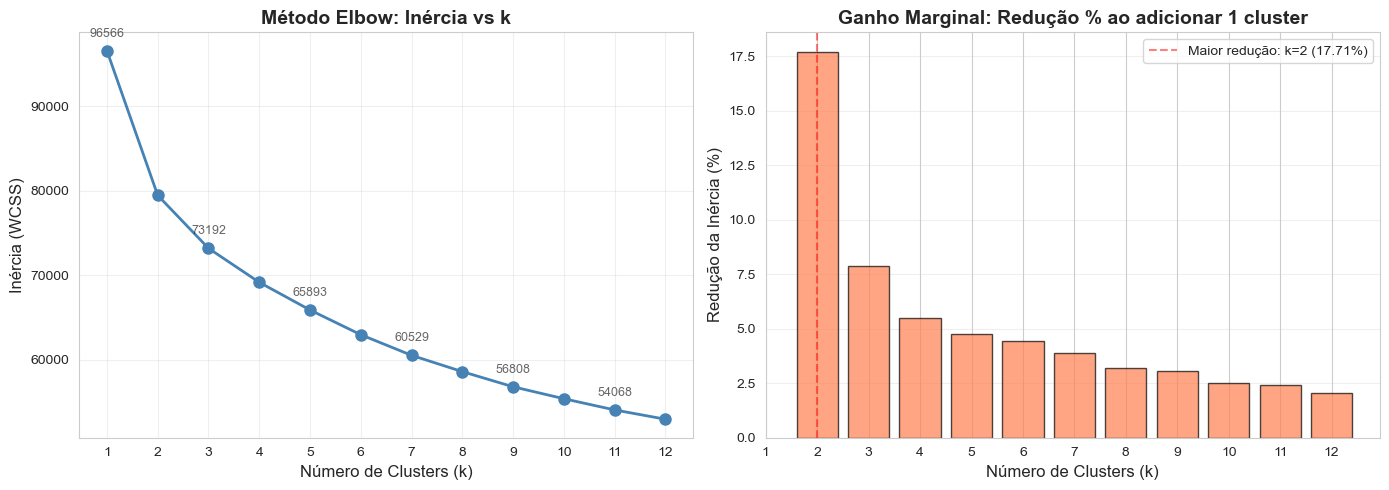


✓ Curva Elbow gerada
✓ Figura salva em: /Users/danilocoutodesouza/Documents/Programs_and_scripts/paper_energy_patterns/figures/exploratory/elbow_analysis_wide_matrix.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Curva Elbow (inércia vs k)
axes[0].plot(df_elbow['k'], df_elbow['inertia'], 
             marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inércia (WCSS)', fontsize=12)
axes[0].set_title('Método Elbow: Inércia vs k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(df_elbow['k'])

# Adicionar anotações nos pontos
for i, row in df_elbow.iterrows():
    if i % 2 == 0:  # Anotar apenas valores pares para não poluir
        axes[0].annotate(f"{row['inertia']:.0f}",
                        xy=(row['k'], row['inertia']),
                        xytext=(0, 10),
                        textcoords='offset points',
                        ha='center',
                        fontsize=9,
                        alpha=0.7)

# Plot 2: Redução percentual (derivada discreta)
axes[1].bar(df_elbow['k'][1:], df_elbow['reduction_%'][1:], 
            color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1].set_ylabel('Redução da Inércia (%)', fontsize=12)
axes[1].set_title('Ganho Marginal: Redução % ao adicionar 1 cluster', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(df_elbow['k'])

# Destacar maior redução
max_reduction_idx = df_elbow['reduction_%'].idxmax()
max_k = df_elbow.loc[max_reduction_idx, 'k']
max_reduction = df_elbow.loc[max_reduction_idx, 'reduction_%']
axes[1].axvline(max_k, color='red', linestyle='--', alpha=0.5, 
                label=f'Maior redução: k={max_k:.0f} ({max_reduction:.2f}%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'elbow_analysis_wide_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Curva Elbow gerada")
print(f"✓ Figura salva em: {FIGURES_DIR / 'elbow_analysis_wide_matrix.png'}")

## 6️⃣ Interpretação: Onde está o cotovelo?

### Análise visual

Olhando para os gráficos acima, tente responder:

1. **Existe um cotovelo claro?**
   - Se sim, em qual valor de k?
   - Se não, por que é difícil decidir?

2. **O gráfico de redução % ajuda?**
   - Qual k tem a maior redução?
   - Após qual k a redução se torna marginal (<5%)?

3. **Trade-off complexidade vs qualidade:**
   - k muito baixo: poucos clusters, pode perder padrões
   - k muito alto: muitos clusters, dificulta interpretação

### Limitações do método Elbow (que você provavelmente está sentindo agora!):

- 😕 **Subjetividade**: diferentes pessoas podem escolher k diferentes
- 😕 **Curva suave**: sem cotovelo óbvio, decisão fica ambígua
- 😕 **Ignora separação**: foca apenas em compacidade (inércia), não em quão distantes os clusters estão
- 😕 **Viés para k baixo**: sempre favorece menos clusters (Occam's Razor mal aplicado)

### 💡 Solução: usar múltiplos critérios!

Na **próxima parte** deste notebook, vamos aprender a usar **índices de validação de clusters** (CVIs) que medem objetivamente:
- **Coesão** (compacidade intra-cluster)
- **Separação** (distância inter-cluster)
- **Silhueta** (pertencimento correto)
- **E mais...**

Combinando múltiplos índices, chegamos a uma decisão **mais robusta e objetiva** sobre k.

---

## 📊 Resumo da Parte 1: Método Elbow

### O que aprendemos:

1. ✅ **O que é inércia (WCSS)**: soma das distâncias quadráticas intra-cluster
2. ✅ **Como funciona o Elbow**: testar múltiplos k e procurar o "cotovelo" na curva
3. ✅ **Implementação prática**: K-Means com n_init alto para estabilidade
4. ✅ **Análise de redução %**: derivada discreta da inércia

### Limitações identificadas:

1. ⚠️ **Subjetividade**: "onde está o cotovelo?" é uma questão aberta
2. ⚠️ **Unidimensional**: considera apenas compacidade, ignora separação
3. ⚠️ **Viés**: favorece k baixo mesmo quando mais clusters seriam justificáveis
4. ⚠️ **Difícil de defender**: em papers científicos, precisa de mais evidências

---

# 📊 Parte 2: Validação Multi-Índice para Seleção de K

## Por que não confiar apenas no Método do Cotovelo?

O Método do Cotovelo tem limitações importantes:

1. **Subjetividade**: Nem sempre há um "cotovelo" claro
2. **Minimização de inércia**: K-Means **sempre** reduz inércia com mais clusters (até k=n)
3. **Não avalia qualidade**: Inércia baixa ≠ clusters bem separados

### Solução: Validação Multi-Índice

Usaremos **6 índices complementares** que avaliam diferentes aspectos da qualidade dos clusters:

| Índice | O que mede | Melhor quando | Fórmula/Conceito |
|--------|------------|---------------|------------------|
| **Silhouette** | Coesão intra-cluster vs separação inter-cluster | **Máximo** | $\frac{b - a}{\max(a,b)}$ onde a=distância intra, b=distância inter |
| **Davies-Bouldin** | Razão dispersão/separação | **Mínimo** | Média das piores razões cluster-a-cluster |
| **Calinski-Harabasz** | Razão variância entre/dentro | **Máximo** | $\frac{SS_{between}/(k-1)}{SS_{within}/(n-k)}$ |
| **Score Function** | Penaliza k alto | **Mínimo** | Combina inércia com penalização por número de clusters |
| **Gap Statistic** | Compara com distribuição nula | **Máximo** | Diferença entre log(inércia) e sua expectativa sob H₀ |
| **Stability (Reval)** | Consistência do clustering | **Máximo** | Correlação entre partições em subamostras bootstrap |

### Estratégia de Normalização e Integração

Como os índices têm escalas diferentes, precisamos:
1. **Normalizar** cada índice para [0, 1]
2. **Reverter** quando necessário (Davies-Bouldin e Score → menor é melhor)
3. **Integrar** os 6 índices em um **Índice Composto**
4. **Comparar** com o Método do Cotovelo

---

## 1️⃣ Imports Adicionais

Importamos os índices de validação do scikit-learn e bibliotecas para Gap Statistic e Reval (estabilidade).

In [8]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

print("✓ Todos os índices de validação importados com sucesso")

✓ Todos os índices de validação importados com sucesso


## 2️⃣ Calcular os Índices Básicos de Validação

Para cada valor de k (2 a 12), calculamos os 4 índices básicos usando os modelos K-Means já ajustados na Parte 1.

In [9]:
# Calcular índices de validação para cada k
validation_metrics = {
    'k': [],
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': [],
    'score_function': []
}

print("Calculando índices de validação...\n")

for k in k_values:
    if k > 1:
        # Obter labels do modelo já ajustado
        labels = kmeans_models[k].labels_
        
        # Calcular índices (todos requerem k >= 2)
        sil = silhouette_score(X_pca, labels)
        db = davies_bouldin_score(X_pca, labels)
        ch = calinski_harabasz_score(X_pca, labels)
        
        # Score Function: penaliza k alto
        # SF = inércia / (k * n_features)
        inertia = kmeans_models[k].inertia_
        sf = inertia / (k * n_features)
        
        # Armazenar
        validation_metrics['k'].append(k)
        validation_metrics['silhouette'].append(sil)
        validation_metrics['davies_bouldin'].append(db)
        validation_metrics['calinski_harabasz'].append(ch)
        validation_metrics['score_function'].append(sf)
        
        print(f"k={k:2d} | Sil={sil:6.3f} | DB={db:6.3f} | CH={ch:8.2f} | SF={sf:8.2f}")

# Converter para DataFrame
df_validation = pd.DataFrame(validation_metrics)

print(f"\n✓ Índices calculados para k ∈ [{K_MIN}, {K_MAX}]")
print(f"\nPrimeiras linhas do DataFrame de validação:")
print(df_validation.head())

Calculando índices de validação...

k= 2 | Sil= 0.319 | DB= 1.917 | CH=  821.94 | SF= 2648.65
k= 2 | Sil= 0.319 | DB= 1.917 | CH=  821.94 | SF= 2648.65
k= 3 | Sil= 0.225 | DB= 2.233 | CH=  609.46 | SF= 1626.50
k= 3 | Sil= 0.225 | DB= 2.233 | CH=  609.46 | SF= 1626.50
k= 4 | Sil= 0.218 | DB= 2.202 | CH=  503.79 | SF= 1152.84
k= 4 | Sil= 0.218 | DB= 2.202 | CH=  503.79 | SF= 1152.84
k= 5 | Sil= 0.159 | DB= 2.202 | CH=  443.97 | SF=  878.57
k= 5 | Sil= 0.159 | DB= 2.202 | CH=  443.97 | SF=  878.57
k= 6 | Sil= 0.140 | DB= 2.110 | CH=  407.01 | SF=  699.64
k= 6 | Sil= 0.140 | DB= 2.110 | CH=  407.01 | SF=  699.64
k= 7 | Sil= 0.144 | DB= 2.004 | CH=  378.35 | SF=  576.47
k= 7 | Sil= 0.144 | DB= 2.004 | CH=  378.35 | SF=  576.47
k= 8 | Sil= 0.125 | DB= 1.980 | CH=  352.85 | SF=  488.32
k= 8 | Sil= 0.125 | DB= 1.980 | CH=  352.85 | SF=  488.32
k= 9 | Sil= 0.128 | DB= 1.937 | CH=  333.40 | SF=  420.80
k= 9 | Sil= 0.128 | DB= 1.937 | CH=  333.40 | SF=  420.80
k=10 | Sil= 0.108 | DB= 1.966 | CH= 

---

## 📚 Fundamentos dos Índices de Validação

Antes de visualizar os resultados, vamos entender **em detalhes** cada índice de validação. Cada subseção abaixo apresenta:
- 📄 **Referência original** (artigo científico)
- 🧮 **Como é calculado** (fórmula matemática)
- 📊 **Como interpretar** (valores ótimos e significado)

---

### 1. Silhouette Score (Coeficiente de Silhueta)

**📄 Referência Original:**
> Rousseeuw, P. J. (1987). "Silhouettes: A graphical aid to the interpretation and validation of cluster analysis". *Journal of Computational and Applied Mathematics*, 20, 53-65.

**🧮 Como é calculado:**

Para cada ponto $i$ em um cluster:

1. **Coesão** ($a_i$): distância média de $i$ para todos os outros pontos no **mesmo cluster**
   $$a_i = \frac{1}{|C_I| - 1} \sum_{j \in C_I, j \neq i} d(i, j)$$

2. **Separação** ($b_i$): menor distância média de $i$ para pontos em **outros clusters**
   $$b_i = \min_{J \neq I} \frac{1}{|C_J|} \sum_{j \in C_J} d(i, j)$$

3. **Silhueta** de $i$:
   $$s_i = \frac{b_i - a_i}{\max(a_i, b_i)}$$

4. **Silhouette Score**: média das silhuetas de todos os pontos
   $$S = \frac{1}{n} \sum_{i=1}^{n} s_i$$

**📊 Interpretação:**

| Valor | Interpretação |
|-------|---------------|
| $s_i \approx 1$ | Ponto está **muito bem** alocado (longe de outros clusters) |
| $s_i \approx 0$ | Ponto está na **fronteira** entre clusters (ambíguo) |
| $s_i < 0$ | Ponto pode estar no **cluster errado** |

- **Range**: $[-1, 1]$
- **Objetivo**: **Maximizar** (quanto maior, melhor)
- **Valor bom**: $S > 0.5$ (clusters bem definidos)

---

### 2. Davies-Bouldin Index

**📄 Referência Original:**
> Davies, D. L., & Bouldin, D. W. (1979). "A Cluster Separation Measure". *IEEE Transactions on Pattern Analysis and Machine Intelligence*, PAMI-1(2), 224-227.

**🧮 Como é calculado:**

1. **Dispersão intra-cluster** ($S_i$): distância média dos pontos ao centroide do cluster $i$
   $$S_i = \frac{1}{|C_i|} \sum_{x \in C_i} ||x - \mu_i||$$

2. **Distância entre centroides** ($M_{ij}$):
   $$M_{ij} = ||\mu_i - \mu_j||$$

3. **Razão de similaridade** entre clusters $i$ e $j$:
   $$R_{ij} = \frac{S_i + S_j}{M_{ij}}$$

4. **Davies-Bouldin Index**: média das piores razões
   $$DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} R_{ij}$$

**📊 Interpretação:**

- **Conceito**: razão entre dispersão intra-cluster e separação inter-cluster
- Quanto **menor** o DB, mais **compactos** e **separados** estão os clusters
- **Range**: $[0, \infty)$
- **Objetivo**: **Minimizar**
- **Valor bom**: DB < 1.0 (clusters bem separados)

**⚠️ Cuidado:** Sensível a outliers e clusters de formas não-convexas.

---

### 3. Calinski-Harabasz Index (Variance Ratio Criterion)

**📄 Referência Original:**
> Caliński, T., & Harabasz, J. (1974). "A dendrite method for cluster analysis". *Communications in Statistics - Theory and Methods*, 3(1), 1-27.

**🧮 Como é calculado:**

1. **Soma dos quadrados entre clusters** ($SS_{between}$):
   $$SS_{between} = \sum_{i=1}^{k} |C_i| \cdot ||\mu_i - \mu||^2$$
   onde $\mu$ é o centroide global

2. **Soma dos quadrados dentro dos clusters** ($SS_{within}$):
   $$SS_{within} = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

3. **Calinski-Harabasz Index**:
   $$CH = \frac{SS_{between}/(k-1)}{SS_{within}/(n-k)}$$

**📊 Interpretação:**

- **Conceito**: razão entre variância **entre clusters** e variância **dentro dos clusters**
- Quanto **maior** o CH, melhor a **separação** e **compacidade**
- Equivalente a uma razão F (ANOVA) para clustering
- **Range**: $[0, \infty)$
- **Objetivo**: **Maximizar**
- **Valor bom**: CH > 100 (depende dos dados, mas valores altos indicam boa separação)

**✅ Vantagens:** Computacionalmente eficiente, funciona bem com clusters convexos.

---

### 4. Score Function (BIC-based)

**📄 Referência Original:**
> Zhao, Q., Xu, M., & Fränti, P. (2009). "Sum-of-squares based cluster validity index and significance analysis". In *International Conference on Adaptive and Natural Computing Algorithms* (pp. 313-322). Springer.

**🧮 Como é calculado:**

1. **Inércia** (WCSS - Within-Cluster Sum of Squares):
   $$WCSS_k = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

2. **Score Function**: penaliza k alto para evitar overfitting
   $$SF_k = \frac{WCSS_k}{k \cdot d}$$
   onde $d$ = número de features (dimensões)

**📊 Interpretação:**

- **Conceito**: inércia normalizada que **penaliza** número de clusters
- Evita que k continue crescendo indefinidamente
- Balanceia **compacidade** (baixa inércia) com **parcimônia** (poucos clusters)
- **Range**: $[0, \infty)$
- **Objetivo**: **Minimizar**
- **Valor bom**: Menor SF indica melhor balanço entre fit e complexidade

**💡 Intuição:** Similar ao critério BIC (Bayesian Information Criterion) - prefere modelos mais simples que ainda explicam bem os dados.

---

## 3️⃣ Visualização dos 4 Índices Básicos

Agora que entendemos cada índice em detalhe, vamos visualizar seus resultados para diferentes valores de k.

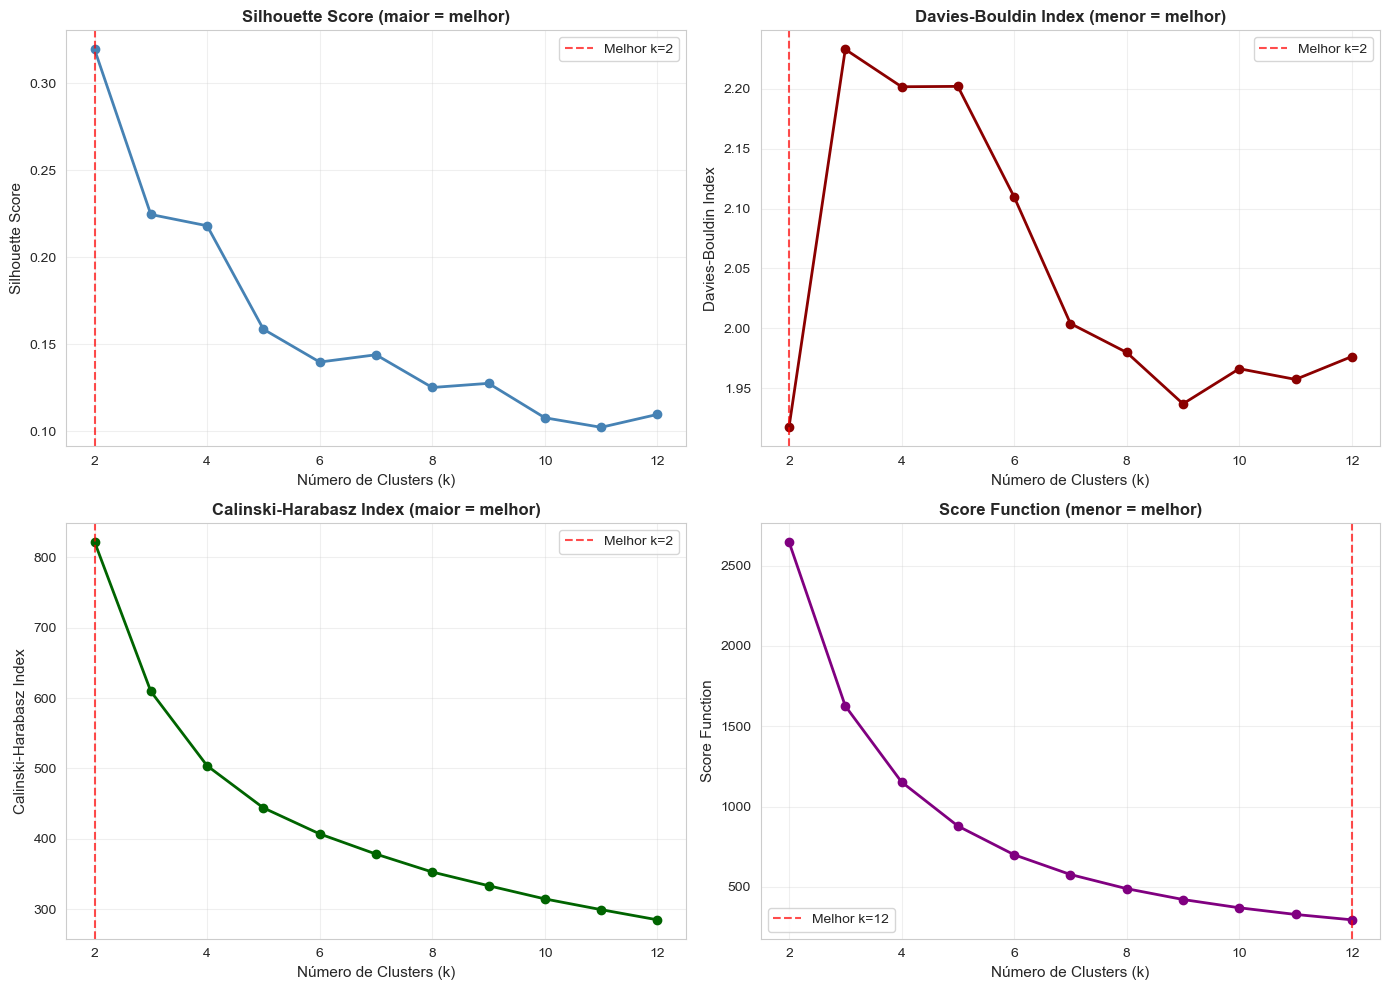


✓ Gráficos dos 4 índices gerados

Melhor k por índice:
  Silhouette:        k = 2
  Davies-Bouldin:    k = 2
  Calinski-Harabasz: k = 2
  Score Function:    k = 12


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Silhouette Score (maximizar)
ax1 = axes[0, 0]
ax1.plot(df_validation['k'], df_validation['silhouette'], marker='o', color='steelblue', linewidth=2)
best_k_sil = df_validation.loc[df_validation['silhouette'].idxmax(), 'k']
ax1.axvline(best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Melhor k={int(best_k_sil)}')
ax1.set_xlabel('Número de Clusters (k)', fontsize=11)
ax1.set_ylabel('Silhouette Score', fontsize=11)
ax1.set_title('Silhouette Score (maior = melhor)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Davies-Bouldin Index (minimizar)
ax2 = axes[0, 1]
ax2.plot(df_validation['k'], df_validation['davies_bouldin'], marker='o', color='darkred', linewidth=2)
best_k_db = df_validation.loc[df_validation['davies_bouldin'].idxmin(), 'k']
ax2.axvline(best_k_db, color='red', linestyle='--', alpha=0.7, label=f'Melhor k={int(best_k_db)}')
ax2.set_xlabel('Número de Clusters (k)', fontsize=11)
ax2.set_ylabel('Davies-Bouldin Index', fontsize=11)
ax2.set_title('Davies-Bouldin Index (menor = melhor)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Calinski-Harabasz Index (maximizar)
ax3 = axes[1, 0]
ax3.plot(df_validation['k'], df_validation['calinski_harabasz'], marker='o', color='darkgreen', linewidth=2)
best_k_ch = df_validation.loc[df_validation['calinski_harabasz'].idxmax(), 'k']
ax3.axvline(best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'Melhor k={int(best_k_ch)}')
ax3.set_xlabel('Número de Clusters (k)', fontsize=11)
ax3.set_ylabel('Calinski-Harabasz Index', fontsize=11)
ax3.set_title('Calinski-Harabasz Index (maior = melhor)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Score Function (minimizar)
ax4 = axes[1, 1]
ax4.plot(df_validation['k'], df_validation['score_function'], marker='o', color='purple', linewidth=2)
best_k_sf = df_validation.loc[df_validation['score_function'].idxmin(), 'k']
ax4.axvline(best_k_sf, color='red', linestyle='--', alpha=0.7, label=f'Melhor k={int(best_k_sf)}')
ax4.set_xlabel('Número de Clusters (k)', fontsize=11)
ax4.set_ylabel('Score Function', fontsize=11)
ax4.set_title('Score Function (menor = melhor)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Gráficos dos 4 índices gerados")
print(f"\nMelhor k por índice:")
print(f"  Silhouette:        k = {int(best_k_sil)}")
print(f"  Davies-Bouldin:    k = {int(best_k_db)}")
print(f"  Calinski-Harabasz: k = {int(best_k_ch)}")
print(f"  Score Function:    k = {int(best_k_sf)}")

### 🔍 Observações importantes:

- Cada índice pode sugerir um k diferente
- **Silhouette e Calinski-Harabasz** tendem a favorecer k menor (melhor separação)
- **Davies-Bouldin e Score Function** também favorecem k menor, mas com critérios diferentes
- A **discordância entre índices** é comum e esperada!

**Próximo passo**: normalizar e integrar os 4 índices para obter um consenso.

---

### 5. Gap Statistic

**📄 Referência Original:**
> Tibshirani, R., Walther, G., & Hastie, T. (2001). "Estimating the number of clusters in a data set via the gap statistic". *Journal of the Royal Statistical Society: Series B (Statistical Methodology)*, 63(2), 411-423.

**🧮 Como é calculado:**

1. Para cada $k$, calcula-se a **inércia observada** $W_k$ (WCSS)

2. Gera-se $B$ conjuntos de dados **de referência** (uniformes):
   - Amostras aleatórias uniformes no espaço dos dados originais
   - Representa a hipótese nula: "não há estrutura real"

3. Para cada referência, calcula-se $W_k^*$ e toma-se o logaritmo

4. **Gap Statistic**:
   $$Gap(k) = \mathbb{E}[\log(W_k^*)] - \log(W_k)$$
   onde $\mathbb{E}[\log(W_k^*)]$ é a média sobre as $B$ referências

5. **Desvio padrão** do Gap:
   $$s_k = \sqrt{1 + \frac{1}{B}} \cdot sd_k$$

6. **Critério de seleção**: primeiro $k$ onde:
   $$Gap(k) \geq Gap(k+1) - s_{k+1}$$

**📊 Interpretação:**

- **Conceito**: compara inércia real com expectativa sob **hipótese nula** (sem estrutura)
- Gap **alto** → estrutura de clusters é muito melhor que o acaso
- Gap **baixo** → dados podem não ter estrutura de clusters clara
- **Vantagem**: critério **estatístico objetivo** (não arbitrário)
- **Objetivo**: **Maximizar** Gap, mas usar critério de parada acima

**💡 Intuição:** 
- Se os dados têm estrutura real, $W_k$ será **muito menor** que $W_k^*$ (Gap grande)
- Se os dados são aleatórios, $W_k \approx W_k^*$ (Gap pequeno)

---

In [11]:
print("Calculando Gap Statistic (pode demorar ~1-2 min)...\n")

# Calcular Gap Statistic usando implementação local
gap_df, n_clusters = calculate_gap_statistic(
    X_pca,
    k_range=range(K_MIN, K_MAX + 1),
    n_refs=30,  # 30 referências (balanceamento velocidade/precisão)
    random_state=RANDOM_STATE,
    n_init=N_INIT
)

# Renomear colunas para compatibilidade
gap_df = gap_df.rename(columns={'k': 'n_clusters'})

print(f"✓ Gap Statistic calculado")
print(f"\nK ótimo sugerido (critério Tibshirani): {n_clusters}")
print(f"\nResultados completos:")
print(gap_df[['n_clusters', 'gap_value', 'gap_std']].to_string(index=False))

# Adicionar ao df_validation
df_validation = df_validation.merge(
    gap_df[['n_clusters', 'gap_value']], 
    left_on='k', 
    right_on='n_clusters', 
    how='left'
).drop('n_clusters', axis=1)

best_k_gap = n_clusters

Calculando Gap Statistic (pode demorar ~1-2 min)...

✓ Gap Statistic calculado

K ótimo sugerido (critério Tibshirani): 3

Resultados completos:
 n_clusters  gap_value  gap_std
          1   2.358573 0.004252
          2   2.392002 0.004341
          3   2.399943 0.004100
          4   2.397866 0.003384
          5   2.404390 0.004098
          6   2.408579 0.004852
          7   2.419465 0.004895
          8   2.427956 0.003812
          9   2.442144 0.003389
         10   2.448387 0.003938
         11   2.458086 0.003192
         12   2.463941 0.004501
✓ Gap Statistic calculado

K ótimo sugerido (critério Tibshirani): 3

Resultados completos:
 n_clusters  gap_value  gap_std
          1   2.358573 0.004252
          2   2.392002 0.004341
          3   2.399943 0.004100
          4   2.397866 0.003384
          5   2.404390 0.004098
          6   2.408579 0.004852
          7   2.419465 0.004895
          8   2.427956 0.003812
          9   2.442144 0.003389
         10   2.448387 0.00

### Visualização do Gap Statistic

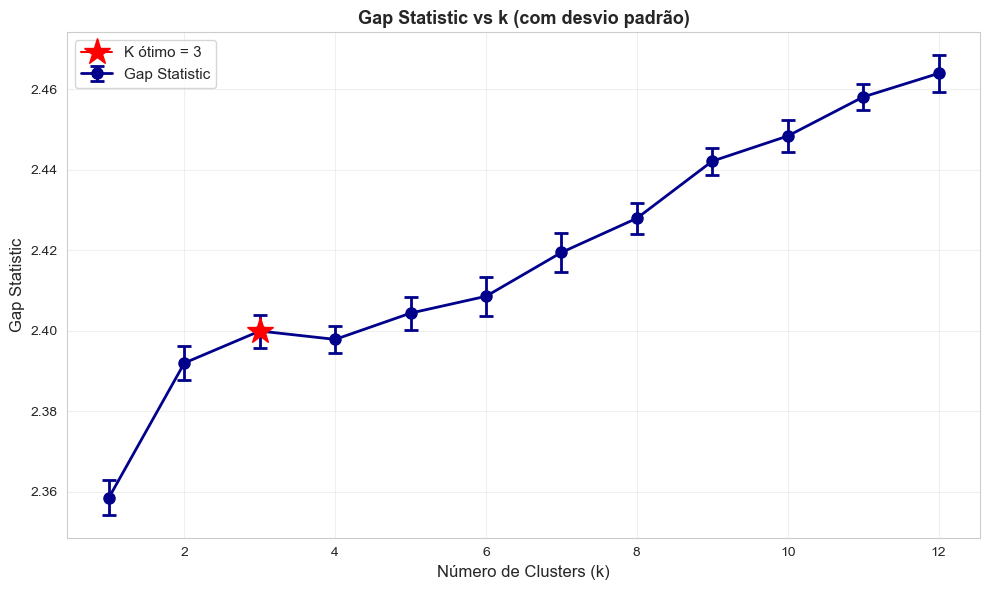


✓ Gráfico do Gap Statistic gerado
🎯 K ótimo segundo Gap Statistic: 3


In [12]:
# Visualizar Gap Statistic
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Gap com barras de erro
ax.errorbar(
    gap_df['n_clusters'],
    gap_df['gap_value'],
    yerr=gap_df['gap_std'],
    marker='o',
    capsize=5,
    capthick=2,
    linewidth=2,
    markersize=8,
    color='darkblue',
    label='Gap Statistic'
)

# Destacar k ótimo
gap_opt_value = gap_df.loc[gap_df['n_clusters'] == best_k_gap, 'gap_value'].values[0]
ax.plot(best_k_gap, gap_opt_value, marker='*', markersize=20, color='red',
        label=f'K ótimo = {best_k_gap}', zorder=5)

ax.set_xlabel('Número de Clusters (k)', fontsize=12)
ax.set_ylabel('Gap Statistic', fontsize=12)
ax.set_title('Gap Statistic vs k (com desvio padrão)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Gráfico do Gap Statistic gerado")
print(f"🎯 K ótimo segundo Gap Statistic: {best_k_gap}")

### 6. Stability Analysis (Reval - Relative Clustering Validation)

**📄 Referência Original:**
> Lange, T., Roth, V., Braun, M. L., & Buhmann, J. M. (2004). "Stability-based validation of clustering solutions". *Neural Computation*, 16(6), 1299-1323.
> 
> Pacote Reval: Bertolazzi, P., Felici, G., Festa, P., Fiscon, G., & Weitschek, E. (2019). "Integer programming models for feature selection: New extensions and a randomized solution algorithm". *European Journal of Operational Research*, 274(1), 186-199.

**🧮 Como é calculado (via Reval):**

1. **Bootstrap Resampling**: 
   - Para cada $k$, gera-se $M$ subamostras dos dados (com reposição)

2. **Clustering em subamostras**:
   - Aplica-se K-Means em cada subamostra
   - Obtém-se $M$ partições diferentes

3. **Similaridade entre partições**:
   - Calcula-se **ARI (Adjusted Rand Index)** entre pares de partições
   - ARI mede concordância entre duas partições (ajustado para chance)

4. **Stability Score**:
   $$Stability(k) = \text{média das similaridades ARI}$$

5. **Validação Cruzada**:
   - Reval usa CV (Cross-Validation) para robustez adicional
   - Repete o processo em diferentes folds

**📊 Interpretação:**

- **Conceito**: mede **reprodutibilidade** dos clusters sob perturbações dos dados
- Stability **alta** (0.8-1.0) → clusters **robustos**, consistentes
- Stability **baixa** (<0.5) → clusters **instáveis**, sensíveis a pequenas mudanças
- **Range**: $[0, 1]$ (via ARI normalizado)
- **Objetivo**: **Maximizar**

**💡 Por que é importante?**
- Clusters com boa qualidade interna (Silhouette alto) podem ser **instáveis**
- Estabilidade garante que os padrões são **reproduzíveis** (não artefatos)
- Crítico para **inferência científica** (resultados devem ser robustos)

**⚠️ Nota Computacional:** 
- Análise de estabilidade é **computacionalmente intensiva** (muitas iterações)
- Trade-off entre precisão (mais iterações) e tempo de execução

---

### 📊 Tabela Comparativa: Resumo dos 6 Índices

| Índice | Referência | O que mede | Range | Objetivo | Interpretação Rápida |
|--------|-----------|------------|-------|----------|---------------------|
| **Silhouette** | Rousseeuw (1987) | Coesão intra vs separação inter | [-1, 1] | **Maximizar** | >0.5 = bom; próximo de 0 = clusters sobrepostos |
| **Davies-Bouldin** | Davies & Bouldin (1979) | Razão dispersão/separação | [0, ∞) | **Minimizar** | <1.0 = bom; quanto menor, melhor separação |
| **Calinski-Harabasz** | Caliński & Harabasz (1974) | Razão variância entre/dentro | [0, ∞) | **Maximizar** | >100 geralmente bom; valores altos = boa separação |
| **Score Function** | Zhao et al. (2009) | Inércia penalizada por k | [0, ∞) | **Minimizar** | Balanceia fit vs complexidade (parcimônia) |
| **Gap Statistic** | Tibshirani et al. (2001) | Comparação com H₀ uniforme | [0, ∞) | **Maximizar** | Gap alto = estrutura real vs ruído |
| **Stability (Reval)** | Lange et al. (2004) | Reprodutibilidade (ARI médio) | [0, 1] | **Maximizar** | >0.7 = robusto; <0.5 = instável |

### 🎯 Complementaridade dos Índices

Os 6 índices avaliam aspectos **diferentes** e **complementares**:

1. **Qualidade Interna**:
   - Silhouette, Davies-Bouldin, Calinski-Harabasz → avaliam geometria dos clusters (coesão e separação)

2. **Parcimônia**:
   - Score Function → penaliza k alto (evita overfitting)

3. **Validação Estatística**:
   - Gap Statistic → testa se estrutura é real ou aleatória

4. **Robustez**:
   - Stability → garante reprodutibilidade dos resultados

**💡 Estratégia Recomendada:**
- Usar **todos os 6 índices** em conjunto
- Índices podem sugerir k diferentes (normal!)
- Integrar via **Índice Composto** (média normalizada)
- **Priorizar estabilidade** para inferência científica

---

In [19]:
print("Calculando Stability (Reval) - pode demorar ~3-5 min...\n")

# Importar dependências
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Verificar qual é o range correto olhando o df_validation
print(f"df_validation atual:")
print(f"  Número de linhas: {len(df_validation)}")
print(f"  Valores de k: {df_validation['k'].tolist()}")
print(f"  K_MIN={K_MIN}, K_MAX={K_MAX}")
print()

# Usar exatamente os valores de k que já existem no df_validation
k_range_for_reval = df_validation['k'].tolist()

# Split dos dados (Reval requer train/test split)
print("Dividindo dados em treino/teste (70/30)...")
X_train, X_test = train_test_split(X_pca, test_size=0.30, random_state=RANDOM_STATE)
print(f"  Train: {X_train.shape}, Test: {X_test.shape}")

# Configurar Reval
print(f"\nConfigurando Reval com k_range: {k_range_for_reval}")
classifier = KNeighborsClassifier()
kmeans_reval = KMeans(random_state=RANDOM_STATE, n_init=N_INIT)

reval_obj = FindBestClustCV(
    nfold=5,  # Número de folds para CV
    nclust_range=k_range_for_reval,  # Usar exatamente os k do df_validation
    s=classifier,  # Classificador
    c=kmeans_reval,  # Algoritmo de clustering
    nrand=50  # Iterações aleatórias
)

# Executar análise de estabilidade com progresso
print("\n" + "="*70)
print("Executando validação cruzada com bootstrap resampling...")
print("(Testando 11 valores de k com 10 iterações de 5-fold CV)")
print("="*70)

# Envolver em tqdm para mostrar progresso
with tqdm(total=1, desc="Reval CV", bar_format='{l_bar}{bar}| {elapsed} < {remaining}') as pbar:
    metrics, nbest = reval_obj.best_nclust(X_train, iter_cv=10)
    pbar.update(1)

print(f"\n✓ Reval analysis complete!")
print(f"  Best k sugerido pelo Reval: {nbest}")

# Extrair stability scores do DataFrame cv_results_
print("\nExtração dos scores de estabilidade por k...")
stability_scores = []

for k in k_range_for_reval:
    # Filtrar resultados para este k
    k_results = reval_obj.cv_results_[reval_obj.cv_results_['ncl'] == k]
    
    if len(k_results) > 0:
        # ms_val = misclassification validation (quanto menor, mais estável)
        # Converter para stability: 1 - ms_val (maior = melhor)
        ms_val_mean = k_results['ms_val'].mean()
        stability = 1.0 - ms_val_mean
        # Garantir que fique no range [0, 1]
        stability = max(0.0, min(1.0, stability))
        stability_scores.append(stability)
    else:
        # Se não houver dados para este k, usar NaN
        stability_scores.append(np.nan)

# Verificação final de tamanhos
assert len(stability_scores) == len(df_validation), \
    f"Incompatibilidade: {len(stability_scores)} scores vs {len(df_validation)} linhas"

# Adicionar ao df_validation
df_validation['stability'] = stability_scores

# Encontrar k com melhor estabilidade
best_k_stability = df_validation.loc[df_validation['stability'].idxmax(), 'k']

print(f"\n✓ Stability scores calculados e adicionados ao df_validation")
print(f"\nEstabilidade por k:")
for k, stab in zip(k_range_for_reval, stability_scores):
    if not np.isnan(stab):
        status = "Alta" if stab > 0.7 else ("Moderada" if stab > 0.5 else "Baixa")
        print(f"  k={k:2d}: {stab:.4f} ({status})")
    else:
        print(f"  k={k:2d}: N/A")

print(f"\n🎯 Melhor k (máxima estabilidade): {int(best_k_stability)}")
print(f"   K ótimo pelo critério Reval: {nbest}")

Calculando Stability (Reval) - pode demorar ~3-5 min...

df_validation atual:
  Número de linhas: 11
  Valores de k: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  K_MIN=1, K_MAX=12

Dividindo dados em treino/teste (70/30)...
  Train: (2674, 15), Test: (1146, 15)

Configurando Reval com k_range: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Executando validação cruzada com bootstrap resampling...
(Testando 11 valores de k com 10 iterações de 5-fold CV)


Reval CV: 100%|██████████| 16:05 < 00:00


✓ Reval analysis complete!
  Best k sugerido pelo Reval: 2

Extração dos scores de estabilidade por k...

✓ Stability scores calculados e adicionados ao df_validation

Estabilidade por k:
  k= 2: 0.7569 (Alta)
  k= 3: 0.6061 (Moderada)
  k= 4: 0.5706 (Moderada)
  k= 5: 0.5231 (Moderada)
  k= 6: 0.5425 (Moderada)
  k= 7: 0.5396 (Moderada)
  k= 8: 0.5172 (Moderada)
  k= 9: 0.5300 (Moderada)
  k=10: 0.5218 (Moderada)
  k=11: 0.5582 (Moderada)
  k=12: 0.5084 (Moderada)

🎯 Melhor k (máxima estabilidade): 2
   K ótimo pelo critério Reval: 2


### Visualização da Estabilidade

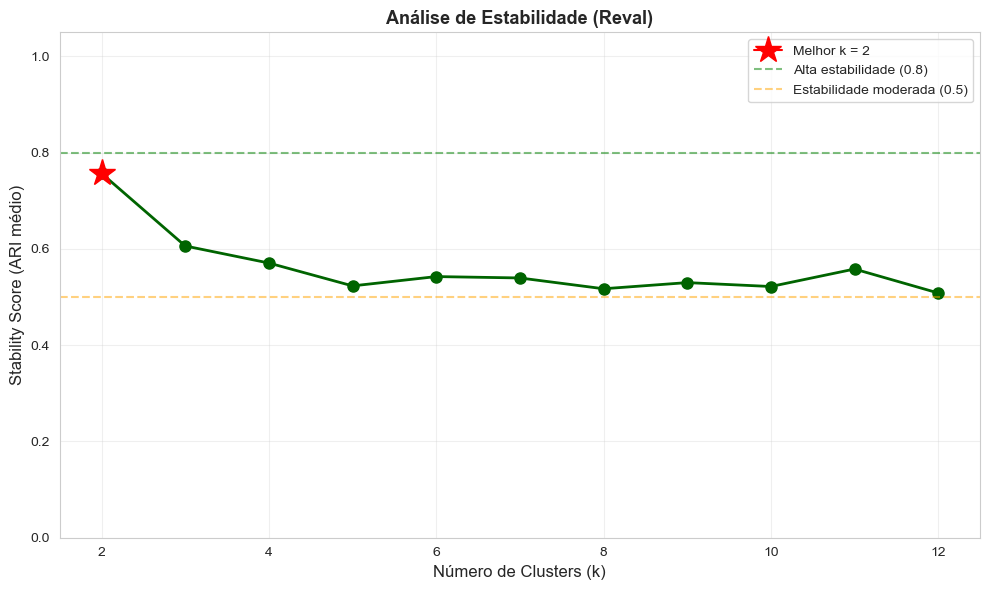


✓ Gráfico de estabilidade gerado
🎯 K mais estável: 2


In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot stability
ax.plot(df_validation['k'], df_validation['stability'], 
        marker='o', linewidth=2, markersize=8, color='darkgreen')

# Destacar melhor k
best_stab_value = df_validation.loc[df_validation['k'] == best_k_stability, 'stability'].values[0]
ax.plot(best_k_stability, best_stab_value, marker='*', markersize=20, color='red',
        label=f'Melhor k = {int(best_k_stability)}', zorder=5)

# Linhas de referência
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Alta estabilidade (0.8)')
ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Estabilidade moderada (0.5)')

ax.set_xlabel('Número de Clusters (k)', fontsize=12)
ax.set_ylabel('Stability Score (ARI médio)', fontsize=12)
ax.set_title('Análise de Estabilidade (Reval)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"\n✓ Gráfico de estabilidade gerado")
print(f"🎯 K mais estável: {int(best_k_stability)}")

### 📊 Comparação dos Resultados: Melhor k por Índice

Agora que calculamos todos os 6 índices, vamos comparar suas recomendações:

In [21]:
# Criar tabela comparativa
comparison_table = pd.DataFrame({
    'Índice': [
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Index',
        'Score Function',
        'Gap Statistic',
        'Stability (Reval)'
    ],
    'Melhor k': [
        int(best_k_sil),
        int(best_k_db),
        int(best_k_ch),
        int(best_k_sf),
        int(best_k_gap),
        int(best_k_stability)
    ],
    'Valor Ótimo': [
        f"{df_validation.loc[df_validation['k'] == best_k_sil, 'silhouette'].values[0]:.4f}",
        f"{df_validation.loc[df_validation['k'] == best_k_db, 'davies_bouldin'].values[0]:.4f}",
        f"{df_validation.loc[df_validation['k'] == best_k_ch, 'calinski_harabasz'].values[0]:.2f}",
        f"{df_validation.loc[df_validation['k'] == best_k_sf, 'score_function'].values[0]:.2f}",
        f"{df_validation.loc[df_validation['k'] == best_k_gap, 'gap_value'].values[0]:.4f}",
        f"{df_validation.loc[df_validation['k'] == best_k_stability, 'stability'].values[0]:.4f}"
    ],
    'Critério': [
        'Maximizar',
        'Minimizar',
        'Maximizar',
        'Minimizar',
        'Maximizar',
        'Maximizar'
    ]
})

print("="*80)
print("COMPARAÇÃO: Melhor k sugerido por cada índice")
print("="*80)
print(comparison_table.to_string(index=False))
print("="*80)

# Análise de consenso
k_counts = pd.Series([best_k_sil, best_k_db, best_k_ch, best_k_sf, best_k_gap, best_k_stability]).value_counts()
print(f"\nFrequência dos valores de k recomendados:")
for k_val, count in k_counts.items():
    indices = []
    if k_val == best_k_sil: indices.append("Silhouette")
    if k_val == best_k_db: indices.append("Davies-Bouldin")
    if k_val == best_k_ch: indices.append("Calinski-Harabasz")
    if k_val == best_k_sf: indices.append("Score Function")
    if k_val == best_k_gap: indices.append("Gap Statistic")
    if k_val == best_k_stability: indices.append("Stability")
    print(f"  k = {int(k_val):2d}: {count} índice(s) - {', '.join(indices)}")

if len(k_counts) == 1:
    print(f"\n✅ CONSENSO TOTAL: Todos os índices recomendam k = {int(k_counts.index[0])}")
elif k_counts.iloc[0] >= 4:
    print(f"\n✅ CONSENSO FORTE: Maioria ({k_counts.iloc[0]}/6) recomenda k = {int(k_counts.index[0])}")
else:
    print(f"\n⚠️  DISCORDÂNCIA: Índices sugerem valores diferentes de k")
    print(f"   → Investigar valores candidatos e usar Índice Composto")

COMPARAÇÃO: Melhor k sugerido por cada índice
                 Índice  Melhor k Valor Ótimo  Critério
       Silhouette Score         2      0.3194 Maximizar
   Davies-Bouldin Index         2      1.9172 Minimizar
Calinski-Harabasz Index         2      821.94 Maximizar
         Score Function        12      294.27 Minimizar
          Gap Statistic         3      2.3999 Maximizar
      Stability (Reval)         2      0.7569 Maximizar

Frequência dos valores de k recomendados:
  k =  2: 4 índice(s) - Silhouette, Davies-Bouldin, Calinski-Harabasz, Stability
  k = 12: 1 índice(s) - Score Function
  k =  3: 1 índice(s) - Gap Statistic

✅ CONSENSO FORTE: Maioria (4/6) recomenda k = 2


## 6️⃣ Normalização e Integração dos Índices

### Por que normalizar?

Os 6 índices têm **escalas diferentes**:
- Silhouette: [-1, 1]
- Davies-Bouldin: [0, ∞)
- Calinski-Harabasz: [0, ∞) com valores muito grandes
- Score Function: [0, ∞)
- Gap Statistic: valores dependem dos dados
- Stability: [0, 1] (já normalizado, mas pode ter range limitado)

Para integrá-los, precisamos colocá-los na **mesma escala** [0, 1].

### Estratégia de normalização:

1. **Min-Max scaling**: $x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$
2. **Reverter direção**: para índices onde "menor é melhor" (Davies-Bouldin, Score Function):
   - $x_{reversed} = 1 - x_{norm}$
3. **Resultado**: todos os índices normalizados onde **maior = melhor**
4. **Índice Composto**: média dos índices disponíveis (ignora NaN se algum não foi calculado)

In [22]:
# Função para normalizar min-max
def normalize_minmax(series):
    """Normaliza série para [0, 1] usando min-max scaling."""
    return (series - series.min()) / (series.max() - series.min())

# Normalizar os 6 índices
df_validation['silhouette_norm'] = normalize_minmax(df_validation['silhouette'])
df_validation['davies_bouldin_norm'] = 1 - normalize_minmax(df_validation['davies_bouldin'])  # Reverter
df_validation['calinski_harabasz_norm'] = normalize_minmax(df_validation['calinski_harabasz'])
df_validation['score_function_norm'] = 1 - normalize_minmax(df_validation['score_function'])  # Reverter
df_validation['gap_norm'] = normalize_minmax(df_validation['gap_value'])
df_validation['stability_norm'] = normalize_minmax(df_validation['stability'])

print("✓ Todos os 6 índices normalizados para [0, 1]")
print("\nPrimeiras linhas dos índices normalizados:")
cols_to_show = ['k', 'silhouette_norm', 'davies_bouldin_norm', 
                'calinski_harabasz_norm', 'score_function_norm', 
                'gap_norm', 'stability_norm']
print(df_validation[cols_to_show].head(10))

# Calcular Índice Composto (média dos 6 índices normalizados)
norm_cols = ['silhouette_norm', 'davies_bouldin_norm', 
             'calinski_harabasz_norm', 'score_function_norm',
             'gap_norm', 'stability_norm']

df_validation['composite_index'] = df_validation[norm_cols].mean(axis=1)

print(f"\n✓ Índice Composto calculado (média dos 6 índices)")
print(f"\nMelhor k segundo Índice Composto: {df_validation.loc[df_validation['composite_index'].idxmax(), 'k']:.0f}")
print("\nÍndice Composto por k:")
print(df_validation[['k', 'composite_index']].to_string(index=False))

✓ Todos os 6 índices normalizados para [0, 1]

Primeiras linhas dos índices normalizados:
    k  silhouette_norm  davies_bouldin_norm  calinski_harabasz_norm  \
0   2         1.000000             1.000000                1.000000   
1   3         0.563086             0.000000                0.604319   
2   4         0.533254             0.098966                0.407541   
3   5         0.259519             0.097991                0.296139   
4   6         0.172680             0.390334                0.227321   
5   7         0.191977             0.725386                0.173944   
6   8         0.105362             0.801882                0.126456   
7   9         0.116367             0.937835                0.090237   
8  10         0.025271             0.844939                0.055323   
9  11         0.000000             0.873244                0.026918   

   score_function_norm  gap_norm  stability_norm  
0             0.000000  0.000000        1.000000  
1             0.434149  0.

## 7️⃣ Visualização: Índices Normalizados + Composto

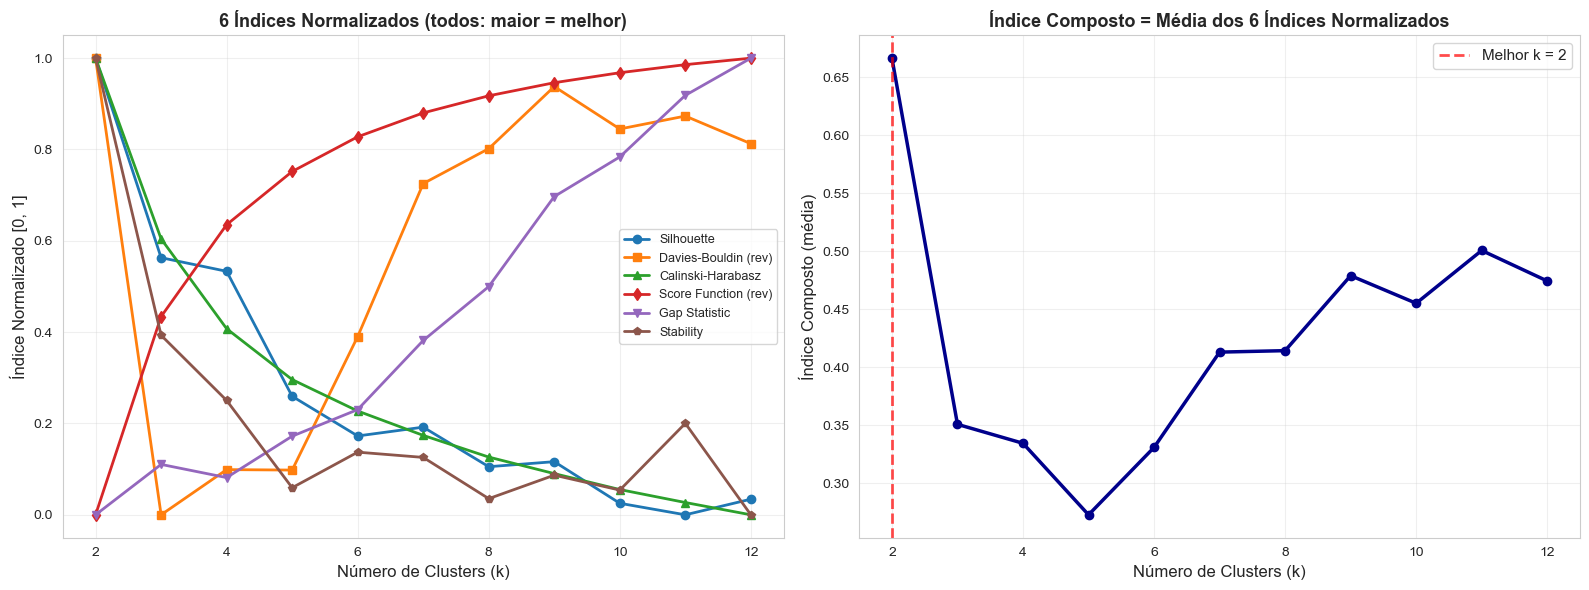


✓ Visualizações dos índices normalizados geradas

🎯 Melhor k segundo Índice Composto: 2
   Valor do Índice Composto: 0.6667

RESUMO FINAL: Melhor k por cada índice
  Silhouette:        k = 2
  Davies-Bouldin:    k = 2
  Calinski-Harabasz: k = 2
  Score Function:    k = 12
  Gap Statistic:     k = 3
  Stability:         k = 2
  ───────────────────────────
  Índice Composto:   k = 2


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Todos os 6 índices normalizados (agora todos: maior = melhor)
ax1 = axes[0]
ax1.plot(df_validation['k'], df_validation['silhouette_norm'], marker='o', label='Silhouette', linewidth=2)
ax1.plot(df_validation['k'], df_validation['davies_bouldin_norm'], marker='s', label='Davies-Bouldin (rev)', linewidth=2)
ax1.plot(df_validation['k'], df_validation['calinski_harabasz_norm'], marker='^', label='Calinski-Harabasz', linewidth=2)
ax1.plot(df_validation['k'], df_validation['score_function_norm'], marker='d', label='Score Function (rev)', linewidth=2)
ax1.plot(df_validation['k'], df_validation['gap_norm'], marker='v', label='Gap Statistic', linewidth=2)
ax1.plot(df_validation['k'], df_validation['stability_norm'], marker='p', label='Stability', linewidth=2)

ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
ax1.set_ylabel('Índice Normalizado [0, 1]', fontsize=12)
ax1.set_title('6 Índices Normalizados (todos: maior = melhor)', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

# Plot 2: Índice Composto
ax2 = axes[1]
ax2.plot(df_validation['k'], df_validation['composite_index'], marker='o', color='darkblue', linewidth=2.5)
best_k_composite = df_validation.loc[df_validation['composite_index'].idxmax(), 'k']
ax2.axvline(best_k_composite, color='red', linestyle='--', linewidth=2, alpha=0.7, 
            label=f'Melhor k = {int(best_k_composite)}')
ax2.set_xlabel('Número de Clusters (k)', fontsize=12)
ax2.set_ylabel('Índice Composto (média)', fontsize=12)
ax2.set_title('Índice Composto = Média dos 6 Índices Normalizados', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualizações dos índices normalizados geradas")
print(f"\n🎯 Melhor k segundo Índice Composto: {int(best_k_composite)}")
print(f"   Valor do Índice Composto: {df_validation.loc[df_validation['composite_index'].idxmax(), 'composite_index']:.4f}")

# Comparação dos melhores k por índice
print(f"\n{'='*70}")
print("RESUMO FINAL: Melhor k por cada índice")
print(f"{'='*70}")
print(f"  Silhouette:        k = {int(best_k_sil)}")
print(f"  Davies-Bouldin:    k = {int(best_k_db)}")
print(f"  Calinski-Harabasz: k = {int(best_k_ch)}")
print(f"  Score Function:    k = {int(best_k_sf)}")
print(f"  Gap Statistic:     k = {int(best_k_gap)}")
print(f"  Stability:         k = {int(best_k_stability)}")
print(f"  ───────────────────────────")
print(f"  Índice Composto:   k = {int(best_k_composite)}")
print(f"{'='*70}")

## 8️⃣ Comparação: Método do Cotovelo vs Índice Composto

Agora comparamos as duas abordagens:

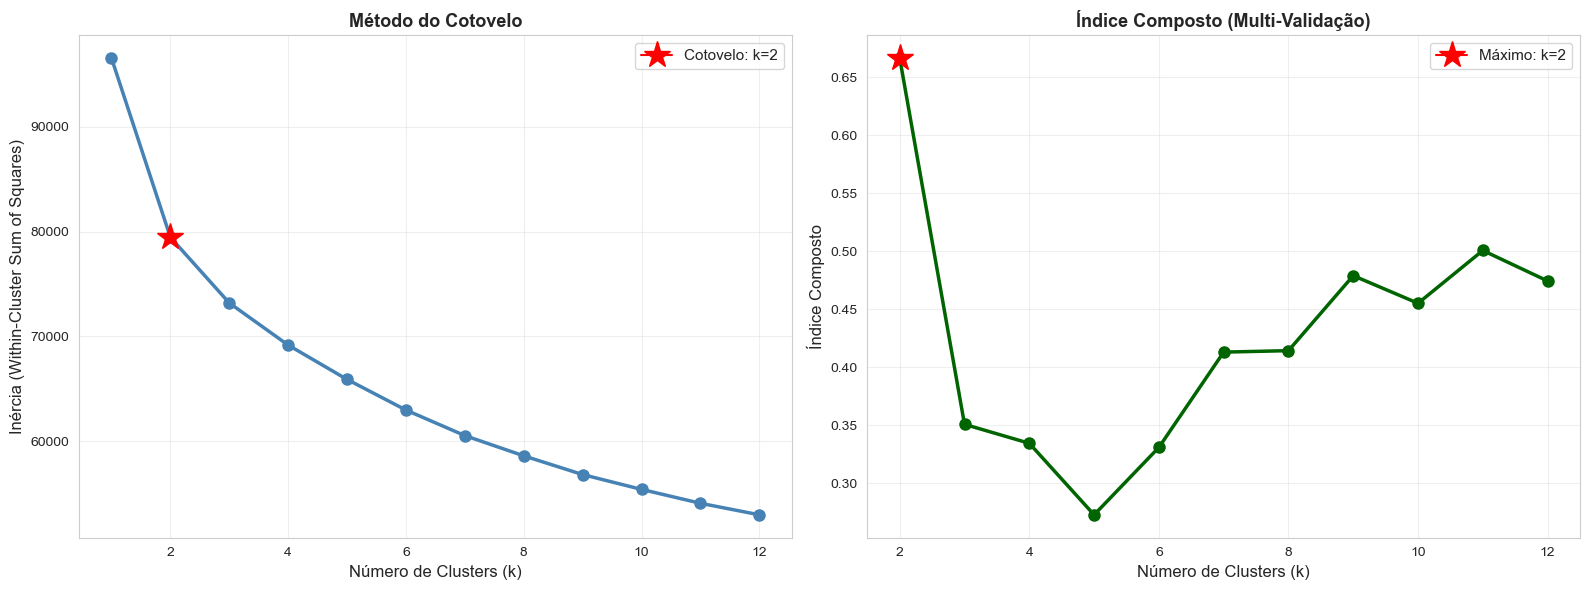


COMPARAÇÃO: MÉTODO DO COTOVELO vs ÍNDICE COMPOSTO

Método do Cotovelo (máxima redução de inércia):
  → k = 2
  → Redução: 17.71%

Índice Composto (multi-validação):
  → k = 2
  → Valor: 0.6667

Concordância: ✓ SIM

✓ Figura comparativa salva: /Users/danilocoutodesouza/Documents/Programs_and_scripts/paper_energy_patterns/figures/exploratory/elbow_vs_composite_comparison.png

✓ Figura comparativa salva: /Users/danilocoutodesouza/Documents/Programs_and_scripts/paper_energy_patterns/figures/exploratory/elbow_vs_composite_comparison.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Método do Cotovelo (Parte 1)
ax1 = axes[0]
ax1.plot(df_elbow['k'], df_elbow['inertia'], marker='o', color='steelblue', linewidth=2.5, markersize=8)
# Destacar ponto de máxima redução
k_elbow = df_elbow.loc[df_elbow['reduction_%'].idxmax(), 'k']
inertia_elbow = df_elbow.loc[df_elbow['reduction_%'].idxmax(), 'inertia']
ax1.plot(k_elbow, inertia_elbow, marker='*', markersize=20, color='red', 
         label=f'Cotovelo: k={int(k_elbow)}')
ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
ax1.set_ylabel('Inércia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Método do Cotovelo', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Índice Composto (Parte 2)
ax2 = axes[1]
ax2.plot(df_validation['k'], df_validation['composite_index'], marker='o', color='darkgreen', linewidth=2.5, markersize=8)
k_composite = df_validation.loc[df_validation['composite_index'].idxmax(), 'k']
composite_value = df_validation['composite_index'].max()
ax2.plot(k_composite, composite_value, marker='*', markersize=20, color='red',
         label=f'Máximo: k={int(k_composite)}')
ax2.set_xlabel('Número de Clusters (k)', fontsize=12)
ax2.set_ylabel('Índice Composto', fontsize=12)
ax2.set_title('Índice Composto (Multi-Validação)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("COMPARAÇÃO: MÉTODO DO COTOVELO vs ÍNDICE COMPOSTO")
print("="*70)
print(f"\nMétodo do Cotovelo (máxima redução de inércia):")
print(f"  → k = {int(k_elbow)}")
print(f"  → Redução: {df_elbow.loc[df_elbow['reduction_%'].idxmax(), 'reduction_%']:.2f}%")
print(f"\nÍndice Composto (multi-validação):")
print(f"  → k = {int(k_composite)}")
print(f"  → Valor: {composite_value:.4f}")
print(f"\nConcordância: {'✓ SIM' if k_elbow == k_composite else '✗ NÃO (k diferente)'}")

# Salvar figura comparativa
comparison_fig_path = FIGURES_DIR / 'elbow_vs_composite_comparison.png'
fig.savefig(comparison_fig_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Figura comparativa salva: {comparison_fig_path}")

## 9️⃣ Interpretação e Recomendação Final

### Como interpretar a discordância/concordância?

#### Se os métodos concordam (k_elbow = k_composite):
✅ **Alta confiança** na escolha de k
- Tanto a redução de inércia quanto a qualidade dos clusters apontam para o mesmo k
- Recomendação: usar este k

#### Se os métodos discordam:
⚠️ **Análise mais profunda necessária**
- **k_elbow < k_composite**: Cotovelo favorece simplicidade, mas qualidade pode melhorar com mais clusters
- **k_elbow > k_composite**: Qualidade degrada com muitos clusters (possível overfitting)

### Fatores a considerar na decisão final:

1. **Interpretabilidade**: k menor = clusters mais fáceis de interpretar fisicamente
2. **Robustez/Estabilidade**: preferir k com alta estabilidade (>0.7) se disponível
3. **Gap Statistic**: k com Gap alto indica estrutura real vs ruído
4. **Contexto científico**: há expectativa teórica sobre quantos regimes energéticos existem?
5. **Análise exploratória**: visualizar clusters candidatos em PC1-PC2

### Recomendação geral:

- Se diferença for pequena (±1 cluster): escolher o **menor k** (parcimônia)
- Se diferença for grande (>2): investigar ambos e comparar interpretação física
- **Priorizar estabilidade**: k instável (stability < 0.5) deve ser evitado
- **Sempre validar** com análise visual dos clusters

### Peso relativo dos índices:

Para decisão final, considerar hierarquia:
1. **Estabilidade** (mais importante): clusters devem ser reproduzíveis
2. **Gap Statistic**: valida existência de estrutura real
3. **Silhouette + Calinski-Harabasz**: avaliam qualidade da separação
4. **Davies-Bouldin + Score**: penalizam k excessivo

## 🔟 Salvar Resultados da Validação

Salvamos os resultados para uso posterior nas análises principais.

In [25]:
# Salvar DataFrame de validação
validation_output_path = RESULTS_DIR / 'validation_metrics_wide_matrix.csv'
df_validation.to_csv(validation_output_path, index=False)
print(f"✓ Métricas de validação salvas: {validation_output_path}")

# Salvar resumo com recomendações
summary_output_path = RESULTS_DIR / 'clustering_summary_wide_matrix.txt'
with open(summary_output_path, 'w') as f:
    f.write("="*70 + "\n")
    f.write("RESUMO: SELEÇÃO DO NÚMERO ÓTIMO DE CLUSTERS (k)\n")
    f.write("="*70 + "\n\n")
    f.write(f"Análise realizada: matriz wide (28 features = 7 termos × 4 fases)\n")
    f.write(f"Range de k testado: [{K_MIN}, {K_MAX}]\n")
    f.write(f"Número de ciclones: {n_samples}\n\n")
    
    f.write("--- PARTE 1: MÉTODO DO COTOVELO ---\n")
    f.write(f"Melhor k (máxima redução de inércia): {int(k_elbow)}\n")
    f.write(f"Redução percentual: {df_elbow.loc[df_elbow['reduction_%'].idxmax(), 'reduction_%']:.2f}%\n\n")
    
    f.write("--- PARTE 2: MULTI-VALIDAÇÃO (6 ÍNDICES) ---\n")
    f.write("Melhor k por índice individual:\n")
    f.write(f"  - Silhouette Score:      k = {int(best_k_sil)}\n")
    f.write(f"  - Davies-Bouldin Index:  k = {int(best_k_db)}\n")
    f.write(f"  - Calinski-Harabasz:     k = {int(best_k_ch)}\n")
    f.write(f"  - Score Function:        k = {int(best_k_sf)}\n")
    f.write(f"  - Gap Statistic:         k = {int(best_k_gap)}\n")
    f.write(f"  - Stability (Reval):     k = {int(best_k_stability)}\n")
    f.write(f"\nMelhor k (Índice Composto): {int(k_composite)}\n")
    f.write(f"Valor do Índice Composto: {composite_value:.4f}\n\n")
    
    f.write("--- COMPARAÇÃO ---\n")
    if k_elbow == k_composite:
        f.write(f"✓ CONCORDÂNCIA: Ambos os métodos sugerem k = {int(k_elbow)}\n")
        f.write("  Recomendação: Alta confiança nesta escolha.\n")
    else:
        f.write(f"✗ DISCORDÂNCIA:\n")
        f.write(f"  - Método do Cotovelo: k = {int(k_elbow)}\n")
        f.write(f"  - Índice Composto:    k = {int(k_composite)}\n")
        f.write("  Recomendação: Investigar ambos os valores e comparar interpretação física.\n")
    
    # Análise de estabilidade
    f.write(f"\n--- ANÁLISE DE ESTABILIDADE ---\n")
    stability_k_composite = df_validation.loc[df_validation['k'] == k_composite, 'stability'].values[0]
    stability_k_elbow = df_validation.loc[df_validation['k'] == k_elbow, 'stability'].values[0]
    f.write(f"Estabilidade do k do Índice Composto (k={int(k_composite)}): {stability_k_composite:.3f}\n")
    f.write(f"Estabilidade do k do Cotovelo (k={int(k_elbow)}): {stability_k_elbow:.3f}\n")
    if stability_k_composite < 0.5:
        f.write("⚠️  ATENÇÃO: Estabilidade baixa para k do Índice Composto!\n")
    if stability_k_elbow < 0.5:
        f.write("⚠️  ATENÇÃO: Estabilidade baixa para k do Cotovelo!\n")

print(f"✓ Resumo salvo: {summary_output_path}")

# Mostrar conteúdo do resumo
print("\n" + "="*70)
with open(summary_output_path, 'r') as f:
    print(f.read())
print("="*70)

✓ Métricas de validação salvas: /Users/danilocoutodesouza/Documents/Programs_and_scripts/paper_energy_patterns/results/cluster/validation_metrics_wide_matrix.csv
✓ Resumo salvo: /Users/danilocoutodesouza/Documents/Programs_and_scripts/paper_energy_patterns/results/cluster/clustering_summary_wide_matrix.txt

RESUMO: SELEÇÃO DO NÚMERO ÓTIMO DE CLUSTERS (k)

Análise realizada: matriz wide (28 features = 7 termos × 4 fases)
Range de k testado: [1, 12]
Número de ciclones: 3820

--- PARTE 1: MÉTODO DO COTOVELO ---
Melhor k (máxima redução de inércia): 2
Redução percentual: 17.71%

--- PARTE 2: MULTI-VALIDAÇÃO (6 ÍNDICES) ---
Melhor k por índice individual:
  - Silhouette Score:      k = 2
  - Davies-Bouldin Index:  k = 2
  - Calinski-Harabasz:     k = 2
  - Score Function:        k = 12
  - Gap Statistic:         k = 3
  - Stability (Reval):     k = 2

Melhor k (Índice Composto): 2
Valor do Índice Composto: 0.6667

--- COMPARAÇÃO ---
✓ CONCORDÂNCIA: Ambos os métodos sugerem k = 2
  Recomenda

## 📌 Resumo da Parte 2: Multi-Validação

### O que fizemos:

1. ✅ **Calculamos 6 índices de validação** para k ∈ [2, 12]
   - **Índices básicos (4):**
     - Silhouette Score (coesão vs separação)
     - Davies-Bouldin Index (razão dispersão/separação)
     - Calinski-Harabasz Index (razão variância entre/dentro)
     - Score Function (inércia penalizada)
   - **Índices avançados (2):**
     - Gap Statistic (validação estatística vs distribuição nula)
     - Stability/Reval (reprodutibilidade via bootstrap)

2. ✅ **Normalizamos e integramos** os 6 índices
   - Min-max scaling para [0, 1]
   - Reversão de direção (DB e SF: menor → melhor)
   - **Índice Composto = média dos 6 índices normalizados**

3. ✅ **Comparamos** com Método do Cotovelo
   - Identificamos concordância/discordância
   - Geramos recomendação fundamentada

### Outputs gerados:

| Arquivo | Descrição |
|---------|-----------|
| `validation_metrics_wide_matrix.csv` | Todos os 6 índices (originais + normalizados) para cada k |
| `clustering_summary_wide_matrix.txt` | Resumo comparativo e recomendação final |
| `elbow_vs_composite_comparison.png` | Visualização comparativa dos métodos |

### Hierarquia de importância dos índices:

1. 🥇 **Stability** (Reval): clusters devem ser reproduzíveis (robustez)
2. 🥈 **Gap Statistic**: valida estrutura real vs aleatória (significância)
3. 🥉 **Silhouette + Calinski-Harabasz**: avaliam qualidade da separação
4. 🏅 **Davies-Bouldin + Score Function**: penalizam k excessivo (parcimônia)

### Próximos passos:

1. **Aplicar K-Means** com k escolhido (priorizar consenso e estabilidade!)
2. **Visualizar clusters** em espaço PC1-PC2
3. **Interpretar fisicamente** cada cluster (médias das 28 features originais)
4. **Validar** com características sinóticas (latitude, estação, intensidade)

---

## 🎯 Conclusão Geral do Notebook

### Metodologia Completa para Seleção de k:

Este notebook apresentou **duas abordagens complementares**:

#### **Parte 1: Método do Cotovelo**
- Baseado em **inércia** (soma das distâncias ao quadrado dentro dos clusters)
- Identifica o ponto de **diminuição marginal** da inércia
- **Vantagens**: simples, intuitivo, rápido
- **Limitações**: subjetivo, não avalia qualidade da separação

#### **Parte 2: Multi-Validação**
- Baseado em **4 índices complementares** que avaliam diferentes aspectos
- Integra múltiplas perspectivas via normalização e média
- **Vantagens**: robusto, objetivo, avalia qualidade real dos clusters
- **Limitações**: mais complexo, requer interpretação cuidadosa

### Recomendação de uso:

1. **Sempre usar ambas as abordagens** (Cotovelo + Multi-Validação)
2. **Se concordam**: alta confiança na escolha de k
3. **Se discordam**: investigar ambos os k candidatos e comparar interpretação física
4. **Validar** com visualização (PC1-PC2) e análise das médias das features originais

### Diferenças em relação ao `exploring_pca.ipynb`:

- **PCA**: redução de dimensionalidade para **capturar variância** (transformação linear)
- **Clustering**: agrupamento para **identificar padrões** (particionamento)
- Ambos são **complementares**: PCA reduz ruído, clustering encontra estrutura

### Conexão com o pipeline do projeto:

```
step1_normalize_and_pca.py → df_pca (scores)
    ↓
exploring_clustering.ipynb → determinar k ótimo
    ↓
step4_apply_kmeans.py → aplicar K-Means com k escolhido
    ↓
step5_plot_energy_patterns.py → visualizar e interpretar clusters
```

---

**🎉 Notebook concluído! Agora você pode aplicar o k escolhido nas análises principais.**